# Adapted from Wen Wang's code.

# Functions

In [1]:
from scipy.interpolate import pade
from scipy.special import factorial
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np
import math


def taylor_ex(tmu2k2):
    nk = tmu2k2.shape[0]
    tmu2k2 = np.array([(-1)**(k+1) * tmu2k2[k] for k in range(len(tmu2k2))], dtype=float)

    para = np.zeros(nk)
    for i in range(nk):
        para[i] = (-1)**i
    para /= factorial( 2*np.arange(nk) )
    # print(para)
    a2k = para * tmu2k2
    # print(a2k)

    taylor = np.zeros(2*nk-1)
    for i in range(nk):
        taylor[2*i] = a2k[i]
    # print(taylor)

    return taylor

#p00 = np.array([1, 1, 1, 1, 3.6])

infc = np.inf
bounds = ([-infc,-infc,0,0,0], +infc)

def fitfun(t, a1, gamma1, a2, gamma2, w2,funcname):
    if funcname == "gaussian":
        def f(x):
            return np.exp(-x**2)
    elif funcname == "hyperbolic":
        def f(x):
            return 1/np.cosh(x)
    elif funcname == "lorentzian":
        def f(x):
            return 1/(x**2+1)

    return a1 * f(gamma1*t) + a2*f(gamma2*t)*np.cos(w2*t)

def fitfun_hyperbolic(t, a1, gamma1, a2, gamma2, w2):
    funcname = "hyperbolic"
    return fitfun(t, a1, gamma1, a2, gamma2, w2, funcname)


def fitfun_gaussian(t, a1, gamma1, a2, gamma2, w2,):
    funcname = "gaussian"
    return fitfun(t, a1, gamma1, a2, gamma2, w2, funcname)

def fitfun_lorentzian(t, a1, gamma1, a2, gamma2, w2):
    funcname = "lorentzian"
    return fitfun(t, a1, gamma1, a2, gamma2, w2, funcname)

def fft_to_2tsigma(w, a1, gamma1, a2, gamma2, w2,funcname):
    if funcname == "gaussian":
        def f(w, ww, gamma):
            return np.exp(-1/4/(gamma**2)*(w+ww)**2) + np.exp(-1/4/(gamma**2)*(w-ww)**2)
        def part(w, a, gamma, ww):
            return a/2.0*math.pow(np.pi,0.5)/gamma*f(w, ww, gamma)
        return part(w,a1,gamma1,0) + part(w,a2,gamma2,w2)
    elif funcname == "hyperbolic":
        def f(w, ww, gamma):
            return 1./np.cosh(np.pi/2*(w+ww)/gamma) + 1./np.cosh(np.pi/2*(w-ww)/gamma)
        def part(w, a, gamma, ww):
            return a/2.0*np.pi/gamma*f(w, ww, gamma)
        return part(w,a1,gamma1,0) + part(w,a2,gamma2,w2)
    elif funcname == "lorentzian":
        def f(w, ww, gamma):
            return np.exp(-abs(w+ww)/gamma)+np.exp(-abs(w-ww)/gamma)
        def part(w, a, gamma, ww):
            return a/2.0*np.pi/gamma*f(w, ww, gamma)
        return part(w,a1,gamma1,0) + part(w,a2,gamma2,w2)

# Continued fraction reconstruction
def Mii(mu):
    n = mu.size
    Mij = np.zeros([n,n])
    for i in range(n):
        Mij[i,0] = mu[i]/mu[0]
        Mij[i,1] = mu[i]/mu[0]

    for j in range(2,n,1):
        for i in range(n):
            if Mij[j-1,j-1] ==0:
                a = 10e-3
            else:
                a =  Mij[j-1,j-1]
            if Mij[j-2,j-2] ==0:
                b =10e-3
            else:
                b = Mij[j-2,j-2]
            Mij[i,j] = Mij[i,j-1]/a - Mij[i-1,j-2]/b

    return np.diag(Mij)

# Denominator of continued fraction
def denominator(w, Mii, i=1):
    if i==Mii.size-1:
        return math.sqrt(Mii[i])
    else:
        d = denominator(w, Mii, i+1)
        # print(i," ",d)
        return  complex(0,1)*w + Mii[i]/d

def tsigma(w, tmu0, Mii):
    d = denominator(w, Mii)
    # print(d)
    return  tmu0*2/denominator(w, Mii)

In [2]:
# Automatic multi-start search for the existing curve_fit calls.
# This cell intentionally keeps the same curve_fit interface, so summary()
# and T_sigma_from_summary_input() below do not need to be modified.
_curve_fit_single_start = curve_fit
_multistart_cache = {}
multistart_fit_results = []

def curve_fit(f, xdata, ydata, p0=None, *args, **kwargs):
    """Run deterministic multi-start fitting and return the lowest-RSS result."""
    if p0 is None or np.asarray(p0).size != 5:
        return _curve_fit_single_start(f, xdata, ydata, p0=p0,
                                       *args, **kwargs)

    x = np.asarray(xdata, dtype=float)
    y = np.asarray(ydata, dtype=float)
    base = np.asarray(p0, dtype=float)
    bounds_here = kwargs.get("bounds", (-np.inf, np.inf))
    lower = np.broadcast_to(np.asarray(bounds_here[0], dtype=float), base.shape)
    upper = np.broadcast_to(np.asarray(bounds_here[1], dtype=float), base.shape)

    cache_key = (id(f), x.tobytes(), y.tobytes(), tuple(base),
                 tuple(lower), tuple(upper))
    if cache_key in _multistart_cache:
        return _multistart_cache[cache_key]

    time_scale = max(float(np.max(np.abs(x))), 0.1)
    amplitude_scale = max(abs(float(y[0])), 1.0e-10)
    gamma_min, gamma_max = 0.1/time_scale, 8.0/time_scale
    omega_min, omega_max = 0.1/time_scale, 15.0/time_scale

    # Include the user's p0, then sample positive amplitudes, decay rates,
    # and frequencies over a broad logarithmic range.
    starts = [base.copy()]
    rng = np.random.default_rng(20260728)
    for _ in range(31):
        fraction = rng.uniform(0.1, 0.9)
        seed = np.array([
            fraction*amplitude_scale,
            np.exp(rng.uniform(np.log(gamma_min), np.log(gamma_max))),
            (1.0-fraction)*amplitude_scale,
            np.exp(rng.uniform(np.log(gamma_min), np.log(gamma_max))),
            np.exp(rng.uniform(np.log(omega_min), np.log(omega_max))),
        ])
        starts.append(seed)

    best = None
    best_rss = np.inf
    best_start = None

    for seed in starts:
        seed = seed.copy()
        for i in range(seed.size):
            if np.isfinite(lower[i]):
                seed[i] = max(seed[i], lower[i] + 1.0e-12)
            if np.isfinite(upper[i]):
                seed[i] = min(seed[i], upper[i] - 1.0e-12)

        try:
            result = _curve_fit_single_start(
                f, x, y, p0=seed, *args, **kwargs
            )
            popt, pcov = result[:2]
            residual = y - f(x, *popt)
            rss = float(np.dot(residual, residual))
            if np.isfinite(rss) and rss < best_rss:
                best = (popt, pcov)
                best_rss = rss
                best_start = seed.copy()
        except (RuntimeError, ValueError, FloatingPointError):
            continue

    if best is None:
        best = _curve_fit_single_start(
            f, x, y, p0=base, *args, **kwargs
        )
        best_start = base.copy()
        residual = y - f(x, *best[0])
        best_rss = float(np.dot(residual, residual))

    scale = max(float(np.dot(y, y)), 1.0e-30)
    record = {
        "model": f.__name__,
        "initial": best_start,
        "params": best[0],
        "rss": best_rss,
        "nrmse": np.sqrt(best_rss/scale),
        "number_of_starts": len(starts),
    }
    multistart_fit_results.append(record)
    print("multistart best:", record)

    _multistart_cache[cache_key] = best
    return best

In [3]:
# Optimize the Padé order and fitting interval without changing existing functions.
# This module reuses taylor_ex(), fitfun_hyperbolic(), and the multi-start
# curve_fit wrapper defined above.

def optimize_pade_fit(
    jj,
    orders=None,
    fit_bounds=None,
    p00=None,
    model=None,
    dt=0.01,
    pole_safety_factor=1.10,
    pole_imag_tolerance=1.0e-3,
    nrmse_limit=0.02,
    parameter_change_limit=0.15,
    pade_disagreement_limit=0.05,
):
    """Return the most stable Padé order, fit bound, and model parameters.

    The largest stable bound is preferred. Stability requires: no near-real
    Padé pole near the fit interval, small fit error, small parameter change
    from the preceding bound, and agreement between different Padé orders.
    """
    jj = np.asarray(jj, dtype=float)
    taylor = taylor_ex(jj)
    model = fitfun_hyperbolic if model is None else model
    p00 = (np.array([0.5, 2.0, 0.5, 3.0, 6.0])
           if p00 is None else np.asarray(p00, dtype=float))
    if orders is None:
        orders = [(4,4), (4,6), (6,6), (6,8), (8,8), (8,10)]
    if fit_bounds is None:
        fit_bounds = np.arange(0.4, 1.21, 0.1)

    orders = [tuple(map(int, order)) for order in orders
              if sum(order) <= len(taylor)-1]
    fit_bounds = sorted({float(b) for b in fit_bounds if b > dt})
    if not orders:
        raise ValueError("No requested Padé order is supported by jj")
    if not fit_bounds:
        raise ValueError("fit_bounds must contain a value greater than dt")

    candidates, rejected = [], []
    for order in orders:
        numerator_order, denominator_order = order
        try:
            p, q = pade(taylor, denominator_order, numerator_order)
        except (ValueError, np.linalg.LinAlgError) as error:
            rejected.append({"order": order, "bound": None,
                             "reason": str(error)})
            continue

        poles = np.asarray(q.roots)
        for bound in fit_bounds:
            dangerous_poles = [pole for pole in poles
                if 0 <= pole.real <= pole_safety_factor*bound
                and abs(pole.imag) <= pole_imag_tolerance]
            if dangerous_poles:
                rejected.append({"order": order, "bound": bound,
                    "reason": "near-real Padé pole", "poles": dangerous_poles})
                continue

            t = np.arange(0.0, bound, dt)
            y = np.real_if_close(p(t)/q(t)).astype(float)
            if not np.all(np.isfinite(y)):
                rejected.append({"order": order, "bound": bound,
                                 "reason": "non-finite Padé curve"})
                continue

            try:
                popt, pcov = curve_fit(
                    model, t, y, p0=p00, maxfev=30000,
                    bounds=([0,0,0,0,0], [np.inf,np.inf,np.inf,np.inf,np.inf]))
            except (RuntimeError, ValueError, FloatingPointError) as error:
                rejected.append({"order": order, "bound": bound,
                                 "reason": f"fit failed: {error}"})
                continue

            yfit = model(t, *popt)
            residual = y-yfit
            rss = float(np.dot(residual, residual))
            nrmse = np.sqrt(rss/max(float(np.dot(y, y)), 1.0e-30))
            candidates.append({
                "order": order, "bound": bound, "params": np.asarray(popt),
                "covariance": pcov, "rss": rss, "nrmse": nrmse,
                "t": t, "pade_curve": y, "fitted_curve": yfit,
                "poles": poles})

    if not candidates:
        raise RuntimeError("All Padé order/bound candidates were rejected")

    # Measure parameter stability as the fit bound grows at fixed order.
    for order in orders:
        group = sorted([r for r in candidates if r["order"] == order],
                       key=lambda r: r["bound"])
        previous = None
        for record in group:
            if previous is None:
                record["parameter_change"] = np.nan
            else:
                a, b = record["params"], previous["params"]
                scale = 0.5*(np.abs(a)+np.abs(b)) + 1.0e-8
                record["parameter_change"] = float(np.max(np.abs(a-b)/scale))
            previous = record

    # Measure agreement among Padé curves at the same fitting bound.
    for bound in fit_bounds:
        group = [r for r in candidates if np.isclose(r["bound"], bound)]
        if not group:
            continue
        curves = np.stack([r["pade_curve"] for r in group])
        median_curve = np.median(curves, axis=0)
        norm = max(float(np.dot(median_curve, median_curve)), 1.0e-30)
        for record in group:
            difference = record["pade_curve"]-median_curve
            record["pade_disagreement"] = np.sqrt(
                float(np.dot(difference, difference))/norm)
            record["orders_at_bound"] = len(group)

    stable = []
    for record in candidates:
        change = record["parameter_change"]
        record["stable"] = bool(
            np.isfinite(change) and record["orders_at_bound"] >= 2
            and record["nrmse"] <= nrmse_limit
            and change <= parameter_change_limit
            and record["pade_disagreement"] <= pade_disagreement_limit)
        record["stability_score"] = (
            record["nrmse"]/nrmse_limit
            + (change/parameter_change_limit if np.isfinite(change) else 10.0)
            + record["pade_disagreement"]/pade_disagreement_limit)
        if record["stable"]:
            stable.append(record)

    if stable:
        largest_bound = max(r["bound"] for r in stable)
        finalists = [r for r in stable if np.isclose(r["bound"], largest_bound)]
        best = min(finalists, key=lambda r: r["stability_score"])
        status = "largest stable fitting window"
    else:
        best = min(candidates, key=lambda r: r["stability_score"])
        status = "fallback: no candidate passed every stability threshold"

    print("\nPadé optimization summary")
    print("order   bound      NRMSE      dParams       dPade   stable")
    for record in sorted(candidates, key=lambda r: (r["bound"], r["order"])):
        change = record["parameter_change"]
        change_text = f"{change:9.3e}" if np.isfinite(change) else "      nan"
        print(f"{str(record['order']):>8} {record['bound']:6.2f} "
              f"{record['nrmse']:11.3e} {change_text} "
              f"{record['pade_disagreement']:11.3e} {record['stable']}")
    print("selection:", status)
    print("best order:", best["order"])
    print("best bound:", best["bound"])
    print("best parameters:", best["params"])

    return {"best_order": best["order"], "best_bound": best["bound"],
            "best_params": best["params"], "best_record": best,
            "selection_status": status, "candidates": candidates,
            "rejected": rejected}

# Usage after jj_in and p001 are defined:
# optimization = optimize_pade_fit(jj_in*4, p00=p001)
# res = summary(jj_in*4, optimization["best_order"],
#               optimization["best_bound"], optimization["best_params"])


In [7]:
def summary(jj,order,bound,p00):
    taylor = taylor_ex(jj)
    orders = np.array([(4,4),(4,6),(6,6),(6,8),order])

    for order in orders:
        order1, order2 = order
        p,q = pade(taylor,order2,order1)

        x = np.arange(0,5,0.01)
        y = p(x)/q(x)
        plt.plot(x, y, label = f"pade[{order1}/{order2}]" )
    plt.plot(x, np.zeros(x.shape[0]), "k--")

    plt.legend(loc='upper right')
    #plt.ylim(0.8,1)
    plt.show()

    ##############################
    t = np.arange(0,bound,0.01)
    y = p(t)/q(t)

    plt.plot(t, y ,label=f"pade[{order1}/{order2}]")
    #p00 = p001 #np.array([0.5, 2.5, 0.5,2.3, 0.5])
    popt1, pcov = curve_fit(fitfun_hyperbolic, t, y, p0=p00,maxfev = 12000,
                           bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
    print(popt1)
    plt.plot(t, fitfun_hyperbolic(t, *popt1),label='hyperbolic')


    # Gaussian fit
    t = np.arange(0,bound,0.01)
    y = p(t)/q(t)
    #p00 = p001  #np.array([0.5, 2.5, 0.5,2.3, 0.5])
    popt, pcov = curve_fit(fitfun_gaussian, t, y, p0 = p00,maxfev = 12000,
                          bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
    print(popt)
    plt.plot(t, fitfun_gaussian(t, *popt),label='gaussian')

    # Lorentzian fit
    t = np.arange(0,bound,0.01)
    y = p(t)/q(t)
    #p00 = p001  #np.array([0.5, 2.5, 0.5,2.3, 0.5])
    popt, pcov = curve_fit(fitfun_lorentzian, t, y, p0 = p00,maxfev = 12000,
                          bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
    print(popt)
    plt.plot(t, fitfun_lorentzian(t, *popt),label='lorentzian')


    plt.legend(loc='upper right')
    plt.savefig("lorentzian.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    ##############################

    ts = np.arange(0,bound,0.01)
    ys = p(ts)/q(ts)
    #p00 = p001 #np.array([0.5, 2.5, 0.5,2.3, 0.5])
    popt, pcov = curve_fit(fitfun_hyperbolic, ts, ys,p0 =p00,maxfev = 12000,
                           bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
    #omega range
    #nomega=100, dw=0.12, ws=np.arange(0.06,12.0,dw)
    #nomega=200, dw=0.06, ws=np.arange(0.03,12.0,dw)
    dw = 0.06
    ws = np.arange(0.03,12.0,dw)
    print("number of omegas =", str(ws.size))
    print("max omega =", str(ws[-1]))
    sigma2t = np.zeros(ws.size)
    for i, w in enumerate(ws):
        sigma2t[i] = fft_to_2tsigma(w,*popt,"hyperbolic")
    plt.plot(ws, sigma2t/2, label = "hyperbolic")
    print("Tsigma_hyp =", sigma2t[0]/2)
    print("slope_hyp =", 2/sigma2t[0])
    #print("Tsigma(omega) =", sigma2t/2)

    #for annealing
    maxT = 8
    A = sigma2t/2 * dw / maxT / np.pi
    A = A / A.sum()
    print("reconstructed A =", ",".join(str(A[i]) for i in range(A.size)))

    #ts = np.arange(0,bound,0.01)
    #ys = p(ts)/q(ts)
    #p00 = p001 #np.array([0.5, 2.5, 0.5,2.3, 0.5])
    #popt, pcov = curve_fit(fitfun_gaussian, ts, ys,p0 =p00,maxfev = 12000,
    #                       bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
    #ws = np.arange(0,10,0.01)
    #sigma2t = np.zeros(ws.size)
    #for i, w in enumerate(ws):
    #    sigma2t[i] = fft_to_2tsigma(w,*popt,"gaussian")
    #plt.plot(ws, sigma2t/2, label = "gaussian")
    #print("Tsigma_gau =", sigma2t[0]/2)

    #ts = np.arange(0,bound,0.01)
    #ys = p(ts)/q(ts)
    #p00 = p001 #np.array([0.5, 2.5, 0.5,2.3, 0.5])
    #popt, pcov = curve_fit(fitfun_lorentzian, ts, ys,p0 =p00,maxfev = 12000,
    #                      bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
    #ws = np.arange(0,10,0.01)
    #sigma2t = np.zeros(ws.size)
    #for i, w in enumerate(ws):
    #    sigma2t[i] = fft_to_2tsigma(w,*popt,"lorentzian")
    #plt.plot(ws, sigma2t/2, label = "lorentzian")
    #print("Tsigma_lor =", sigma2t[0]/2)

    plt.legend()
    plt.show()

    return popt1

# U=-6, t'=0, $n_{\text{flux}}$=0


*   n=1: jj_in= -0.25000000000000000000,4.50000000000000000000,-238.50000000000000000000,19368.00000000000000000000,-2165620.50000000000000000000,317842321.50000000000000000000,-59155482330.00000000000000000000,13549820391900.00000000000000000000,-3709708445407668.50000000000000000000,1180143948105995008.00000000000000000000
*   n=0.9: jj_in= -0.24750000000000002554,4.41045000000000264606,-233.75385000000008517418,18979.40127599991319584660,-2120786.05265999585390090942,310838534.44067746400833129883,-57729048692.12611389160156250000,13187571639708.70507812500000000000,-3600141337521104.50000000000000000000,1142159178031242240.00000000000000000000
*   n=0.8: jj_in= -0.23999999999999999112,4.14719999999999977547,-219.80159999999995079634,17837.60486399992805672809,-1989296.54783999524079263210,290374035.84330713748931884766,-53583504259.01075744628906250000,12141240546827.57031250000000000000,-3285527052144337.00000000000000000000,1033648438345567744.00000000000000000000
*   n=0.7: jj_in= -0.22749999999999998002,3.72644999999999848583,-197.50184999999996193765,16014.49340399999709916301,-1780129.63673999253660440445,258062410.26147258281707763672,-47108976990.60847473144531250000,10527424155466.76171875000000000000,-2806139868088238.00000000000000000000,870061191176669312.00000000000000000000
*   n=0.6: jj_in= -0.20999999999999999223,3.17519999999999935625,-168.28560000000010177246,13629.48249599993869196624,-1508035.20336000667884945869,216503575.44309765100479125977,-38919136822.61341857910156250000,8525331109322.79101562500000000000,-2222685643022853.00000000000000000000,674317419602083072.00000000000000000000




In [27]:
jj_in = np.array([
-0.25000000000000000000,4.50000000000000000000,-238.50000000000000000000,19368.00000000000000000000,-2165620.50000000000000000000,317842321.50000000000000000000,-59155482330.00000000000000000000,13549820391900.00000000000000000000,-3709708445407668.50000000000000000000,1180143948105995008.00000000000000000000
], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

optimization = optimize_pade_fit(
    jj_in*4,
    p00=p001
)

print("Best Padé Order:", optimization["best_order"])
print("Best fitting intervel:", optimization["best_bound"])
print("Best fitting parameters:", optimization["best_params"])
print("Selection status:", optimization["selection_status"])


Padé optimization summary
order   bound      NRMSE      dParams       dPade   stable
  (4, 4)   0.40   4.225e-06       nan   6.420e-04 False
  (4, 6)   0.40   2.163e-05       nan   5.538e-05 False
  (6, 6)   0.40   2.795e-05       nan   2.525e-06 False
  (6, 8)   0.40   2.757e-05       nan   8.928e-08 False
  (8, 8)   0.40   2.755e-05       nan   7.320e-09 False
 (8, 10)   0.40   2.755e-05       nan   7.320e-09 False
  (4, 4)   0.50   2.732e-05 7.569e-01   4.175e-03 False
  (4, 6)   0.50   6.245e-05 3.679e-02   5.211e-04 True
  (6, 6)   0.50   1.299e-04 4.164e-02   3.976e-05 True
  (6, 8)   0.50   1.232e-04 4.110e-02   2.066e-06 True
  (8, 8)   0.50   1.227e-04 4.106e-02   2.581e-07 True
 (8, 10)   0.50   1.229e-04 4.108e-02   2.581e-07 True
  (4, 4)   0.60   1.805e-04 2.000e+00   1.662e-02 False
  (4, 6)   0.60   9.445e-05 8.838e-02   2.700e-03 True
  (6, 6)   0.60   3.948e-04 5.795e-02   3.191e-04 True
  (6, 8)   0.60   3.353e-04 5.701e-02   2.217e-05 True
  (8, 8)   0.60   3.291e-0

/var/folders/ly/j_6xywc159g405jwf5y5r5p40000gn/T/ipykernel_51404/4085685909.py:46: DeprecationWarning: `pade` is deprecated and will be removed in SciPy 1.20.0. Use `mpmath.pade` instead.
  p, q = pade(taylor, denominator_order, numerator_order)


/var/folders/ly/j_6xywc159g405jwf5y5r5p40000gn/T/ipykernel_51404/413711183.py:7: DeprecationWarning: `pade` is deprecated and will be removed in SciPy 1.20.0. Use `mpmath.pade` instead.
  p,q = pade(taylor,order2,order1)


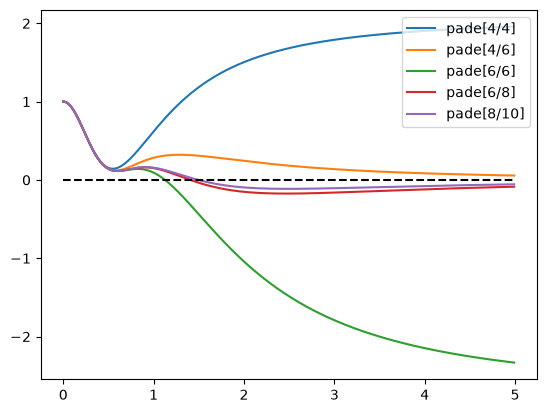

multistart best: {'model': 'fitfun_hyperbolic', 'initial': array([0.61438841, 2.42698571, 0.38727988, 2.51856737, 5.637997  ]), 'params': array([0.61438841, 2.42698571, 0.38727988, 2.51856737, 5.637997  ]), 'rss': 0.0001472729839301841, 'nrmse': np.float64(0.002542275859548848), 'number_of_starts': 32}
[0.61438841 2.42698571 0.38727988 2.51856737 5.637997  ]
multistart best: {'model': 'fitfun_gaussian', 'initial': array([0.52143512, 2.47850799, 0.47856488, 2.95391235, 5.06723663]), 'params': array([0.37506232, 0.93334828, 0.62249421, 1.86718269, 4.49164908]), 'rss': 0.000587095641091094, 'nrmse': np.float64(0.00507592923040565), 'number_of_starts': 32}
[0.37506232 0.93334828 0.62249421 1.86718269 4.49164908]
multistart best: {'model': 'fitfun_lorentzian', 'initial': array([0.38225889, 0.12276604, 0.61774111, 1.71434452, 0.34729774]), 'params': array([0.7963716 , 2.68982722, 0.21275928, 1.48155541, 6.01088646]), 'rss': 0.0026454739896420274, 'nrmse': np.float64(0.01077489082465348), 'nu

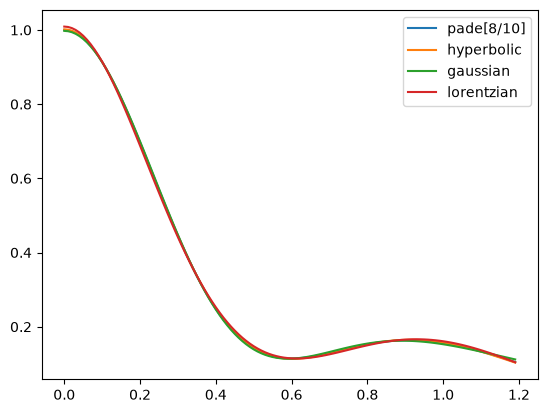

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.4119113872907212
slope_hyp = 2.4277066156809455
reconstructed A = 0.015786415590706676,0.01576423419886423,0.015720044776398222,0.015654190898782585,0.01556718016826148,0.015459675192979638,0.015332482029510116,0.015186536459719086,0.015022888528302804,0.014842685802055083,0.0146471558254859,0.014437588240677523,0.014215317014269474,0.013981703174150617,0.013738118406345623,0.013485929802529587,0.013226485984378446,0.012961104766075955,0.01269106245379008,0.012417584823249143,0.012141839765486034,0.011864931547523843,0.011587896599796298,0.01131170071546164,0.01103723752809314,0.010765328122818133,0.010496721630931244,0.010232096658315348,0.009972063402623663,0.009717166322095598,0.009467887229160886,0.009224648693798364,0.008987817654246553,0.008757709145527672,0.008534590068882072,0.008318682937268465,0.0081101695433194,0.007909194506391872,0.007715868664531627,0.007530272285247438,0.0073524580759830975,0.0071824539

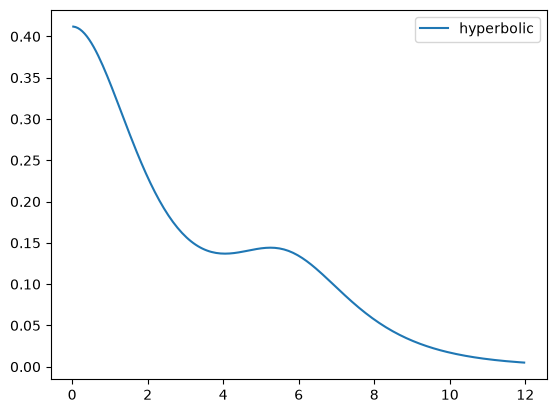

In [28]:
res = summary(
    jj_in*4,
    optimization["best_order"],
    optimization["best_bound"],
    optimization["best_params"]
)

# U=-2, t'=0, $n_{\text{flux}}$=0


*   n=1: jj_in= -0.25000000000000000000,0.50000000000000000000,-10.50000000000000000000,552.00000000000000000000,-46208.50000000000000000000,5131033.50000000000000000000,-688106586.00000000000000000000,105668810316.00000000000000000000,-18000288553203.50000000000000000000,3335629782260335.00000000000000000000
*   n=0.9: jj_in= -0.24750000000000002554,0.49005000000000004112,-10.29105000000000025295,540.97599599999932706851,-45269.99571599987393710762,5023986.35421473532915115356,-673262041.80078160762786865234,103300999562.04957580566406250000,-17580006541159.63671875000000000000,3254290083583894.00000000000000000000
*   n=0.8: jj_in= -0.23999999999999999112,0.46079999999999998739,-9.67679999999999651550,508.57574400000146397360,-42514.45862400039914064109,4710186.15865359362214803696,-629831938.78442597389221191406,96388887140.50067138671875000000,-16356038027188.89453125000000000000,3018002854078054.50000000000000000000
*   n=0.7: jj_in= -0.22749999999999998002,0.41404999999999991811,-8.69504999999999661497,456.81308399999983294038,-38121.11976400015555555001,4211472.35968873649835586548,-561082786.98146343231201171875,85495938920.07890319824218750000,-14436457229753.42968750000000000000,2649318105355279.00000000000000000000
*   n=0.6: jj_in= -0.20999999999999999223,0.35279999999999994698,-7.40879999999999938609,389.03961600000047837966,-32386.37673600001289742067,3563630.62280060397461056709,-472312377.73077970743179321289,71526513663.78570556640625000000,-11992943696956.93359375000000000000,2183696314289672.50000000000000000000

In [10]:
# n=1.0
jj_in = np.array([
    -0.25000000000000000000,0.50000000000000000000,-10.50000000000000000000,552.00000000000000000000,-46208.50000000000000000000,5131033.50000000000000000000,-688106586.00000000000000000000,105668810316.00000000000000000000,-18000288553203.50000000000000000000,3335629782260335.00000000000000000000
    ], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

optimization = optimize_pade_fit(
    jj_in*4,
    p00=p001
)

print("Best Padé Order:", optimization["best_order"])
print("Best fitting intervel:", optimization["best_bound"])
print("Best fitting parameters:", optimization["best_params"])
print("Selection status:", optimization["selection_status"])

/var/folders/ly/j_6xywc159g405jwf5y5r5p40000gn/T/ipykernel_51404/4085685909.py:46: DeprecationWarning: `pade` is deprecated and will be removed in SciPy 1.20.0. Use `mpmath.pade` instead.
  p, q = pade(taylor, denominator_order, numerator_order)


multistart best: {'model': 'fitfun_hyperbolic', 'initial': array([ 0.47284615, 20.35577738,  0.52715385, 14.60186475, 14.04965494]), 'params': array([9.65122452e-01, 1.07292111e+00, 3.48775883e-02, 1.90984946e+00,
       1.25196349e+03]), 'rss': 5.6038125204427255e-14, 'nrmse': np.float64(3.913467544507895e-08), 'number_of_starts': 32}
multistart best: {'model': 'fitfun_hyperbolic', 'initial': array([ 0.50842586,  3.03052193,  0.49157414, 10.60569248,  0.44146806]), 'params': array([0.96010062, 1.05353954, 0.03989967, 1.95494179, 4.42713841]), 'rss': 3.3522916161257937e-12, 'nrmse': np.float64(2.7647122759996253e-07), 'number_of_starts': 32}
multistart best: {'model': 'fitfun_hyperbolic', 'initial': array([0.44390423, 0.63156198, 0.55609577, 5.15008206, 0.75178232]), 'params': array([0.95396351, 1.032618  , 0.04603777, 2.0036181 , 4.16469176]), 'rss': 7.562789201770805e-11, 'nrmse': np.float64(1.2261467792460245e-06), 'number_of_starts': 32}
multistart best: {'model': 'fitfun_hyperboli

/var/folders/ly/j_6xywc159g405jwf5y5r5p40000gn/T/ipykernel_51404/413711183.py:7: DeprecationWarning: `pade` is deprecated and will be removed in SciPy 1.20.0. Use `mpmath.pade` instead.
  p,q = pade(taylor,order2,order1)


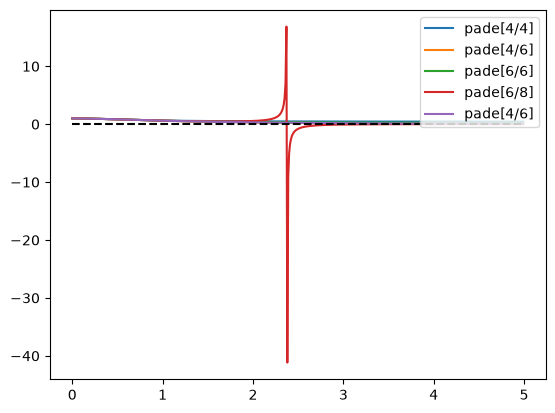

[0.92816338 0.96645787 0.07185874 2.15703413 3.34503732]
multistart best: {'model': 'fitfun_gaussian', 'initial': array([ 0.25446471,  0.11931148,  0.74553529,  8.74302201, 10.8936969 ]), 'params': array([0.84012657, 0.58563564, 0.15966204, 2.08849343, 0.02714846]), 'rss': 2.9869304539905334e-06, 'nrmse': np.float64(0.00021364131204122913), 'number_of_starts': 32}
[0.84012657 0.58563564 0.15966204 2.08849343 0.02714846]
multistart best: {'model': 'fitfun_lorentzian', 'initial': array([0.84009676, 0.55333161, 0.15990324, 0.64325022, 7.21402226]), 'params': array([0.96672611, 0.77819993, 0.03329984, 1.42196848, 4.58749424]), 'rss': 4.3659670951185114e-08, 'nrmse': np.float64(2.582931627402469e-05), 'number_of_starts': 32}
[0.96672611 0.77819993 0.03329984 1.42196848 4.58749424]


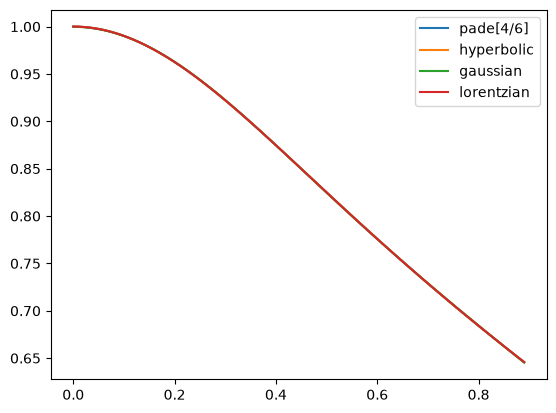

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 1.5158560461983943
slope_hyp = 0.6596932489123183
reconstructed A = 0.0579050431437938,0.05736302780876419,0.05630419685546183,0.05477615765757003,0.0528439003584806,0.05058348488158927,0.048075498589354546,0.04539919638322455,0.0426279220361316,0.03982605378967545,0.03704741805455854,0.03433492239544461,0.03172107612934514,0.029229068442166956,0.02687412547998393,0.02466493911549387,0.022605030451649816,0.020693969802527103,0.01892841835484116,0.017302985747223384,0.015810915147315585,0.014444616243622482,0.01319606975070716,0.012057126778854925,0.011019724325021064,0.010076035240771495,0.009218567957530214,0.00844022834959839,0.0077343535576378875,0.00709472543492463,0.0065155695086148956,0.005991543930352155,0.005517721774357378,0.005089569174696441,0.00470292112860077,0.004353956287670248,0.004039171678472496,0.003755358009915264,0.003499576013976979,0.0032691341109399924,0.0030615675761578942,0.002874619301782862,0

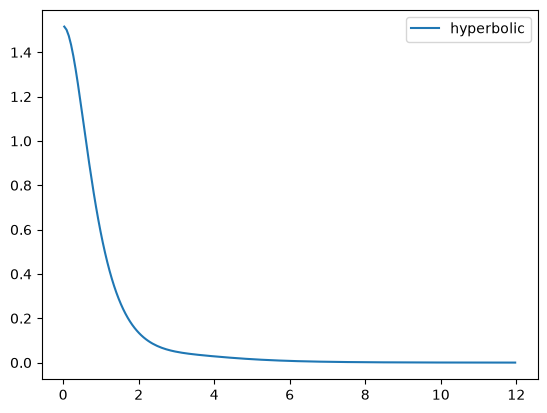

a1 = 0.9281633818266312
gamma1 = 0.9664578746349827
a2 = 0.07185873719408313
gamma2 = 2.1570341293401603
w2 = 3.3450373241717997


In [11]:
res = summary(jj_in*4, (4,6), 0.9, p001)
a1, gamma1, a2, gamma2, w2 = res
print("a1 =", a1)
print("gamma1 =", gamma1)
print("a2 =", a2)
print("gamma2 =", gamma2)
print("w2 =", w2)

In [ ]:
# n=0.9
jj_in = np.array([-0.24750000000000002554,0.49005000000000004112,-10.29105000000000025295,540.97599599999932706851,-45269.99571599987393710762,5023986.35421473532915115356,-673262041.80078160762786865234,103300999562.04957580566406250000,-17580006541159.63671875000000000000,3254290083583894.00000000000000000000], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

res = summary(jj_in*4, (8,10), 1.1, p001)
print(res)

In [ ]:
# n=0.8
jj_in = np.array([-0.23999999999999999112,0.46079999999999998739,-9.67679999999999651550,508.57574400000146397360,-42514.45862400039914064109,4710186.15865359362214803696,-629831938.78442597389221191406,96388887140.50067138671875000000,-16356038027188.89453125000000000000,3018002854078054.50000000000000000000], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

res = summary(jj_in*4, (8,10), 1.1, p001)
print(res)

In [ ]:
# n=0.7
jj_in = np.array([-0.22749999999999998002,0.41404999999999991811,-8.69504999999999661497,456.81308399999983294038,-38121.11976400015555555001,4211472.35968873649835586548,-561082786.98146343231201171875,85495938920.07890319824218750000,-14436457229753.42968750000000000000,2649318105355279.00000000000000000000], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

res = summary(jj_in*4, (8,10), 1.1, p001)
print(res)

In [ ]:
# n=0.6
jj_in = np.array([-0.20999999999999999223,0.35279999999999994698,-7.40879999999999938609,389.03961600000047837966,-32386.37673600001289742067,3563630.62280060397461056709,-472312377.73077970743179321289,71526513663.78570556640625000000,-11992943696956.93359375000000000000,2183696314289672.50000000000000000000], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

res = summary(jj_in*4, (8,10), 1.1, p001)
print(res)

# U=6, t'=0, $n_{\text{flux}}=0$

*   n=1: jj_in= -0.25000000000000000000,4.50000000000000000000,-238.50000000000000000000,19368.00000000000000000000,-2165620.50000000000000000000,317842321.50000000000000000000,-59155482330.00000000000000000000,13549820391900.00000000000000000000,-3709708445407668.50000000000000000000,1180143948105995008.00000000000000000000
*   n=0.9: jj_in= -0.24750000000000002554,4.41045000000000264606,-233.75385000000008517418,18979.40127599991319584660,-2120786.05265999585390090942,310838534.44067746400833129883,-57729048692.12611389160156250000,13187571639708.70507812500000000000,-3600141337521104.50000000000000000000,1142159178031242240.00000000000000000000
*   n=0.8: jj_in= -0.23999999999999999112,4.14719999999999977547,-219.80159999999995079634,17837.60486399992805672809,-1989296.54783999524079263210,290374035.84330713748931884766,-53583504259.01075744628906250000,12141240546827.57031250000000000000,-3285527052144337.00000000000000000000,1033648438345567744.00000000000000000000
*   n=0.7: jj_in= -0.22749999999999998002,3.72644999999999848583,-197.50184999999996193765,16014.49340399999709916301,-1780129.63673999253660440445,258062410.26147258281707763672,-47108976990.60847473144531250000,10527424155466.76171875000000000000,-2806139868088238.00000000000000000000,870061191176669312.00000000000000000000
*   n=0.6: jj_in= -0.20999999999999999223,3.17519999999999935625,-168.28560000000010177246,13629.48249599993869196624,-1508035.20336000667884945869,216503575.44309765100479125977,-38919136822.61341857910156250000,8525331109322.79101562500000000000,-2222685643022853.00000000000000000000,674317419602083072.00000000000000000000


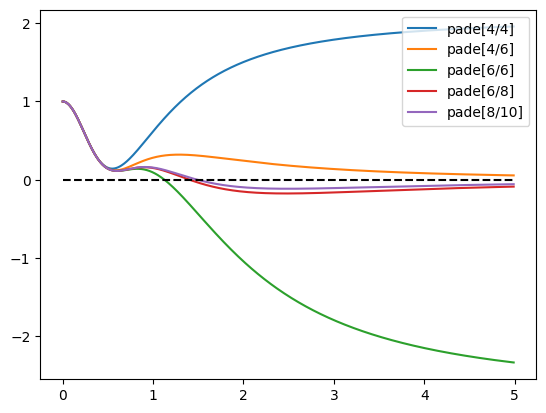

[0.62398477 2.47087786 0.37736639 2.48235592 5.68348361]
[0.33057793 0.84666645 0.66788595 1.95449049 4.25964989]
[0.79026896 2.66350887 0.21846799 1.51065799 5.99075463]


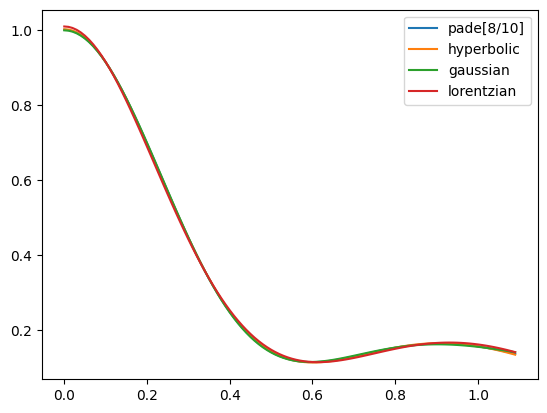

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.4096986034795224
slope_hyp = 2.4408186689120166
Tsigma(omega) = [0.4096986  0.40914109 0.40803027 0.40637447 0.40418601 0.40148097
 0.39827894 0.3946027  0.39047783 0.38593233 0.3809962  0.37570105
 0.3700796  0.36416534 0.35799211 0.3515937  0.34500357 0.33825448
 0.33137828 0.32440565 0.31736594 0.31028699 0.30319504 0.29611462
 0.28906856 0.2820779  0.27516197 0.26833835 0.26162294 0.25503002
 0.24857232 0.24226109 0.23610619 0.23011618 0.2242984  0.21865905
 0.21320331 0.20793541 0.2028587  0.19797576 0.19328844 0.18879794
 0.1845049  0.18040944 0.17651119 0.17280939 0.1693029  0.16599024
 0.16286962 0.15993899 0.15719605 0.15463827 0.15226288 0.15006693
 0.14804725 0.14620047 0.14452302 0.14301114 0.14166082 0.14046784
 0.13942773 0.13853578 0.13778698 0.13717603 0.13669731 0.13634484
 0.13611231 0.135993   0.1359798  0.13606515 0.13624108 0.13649916
 0.13683051 0.13722581 0.13767528 0.13816872 0.13869553 0.13924

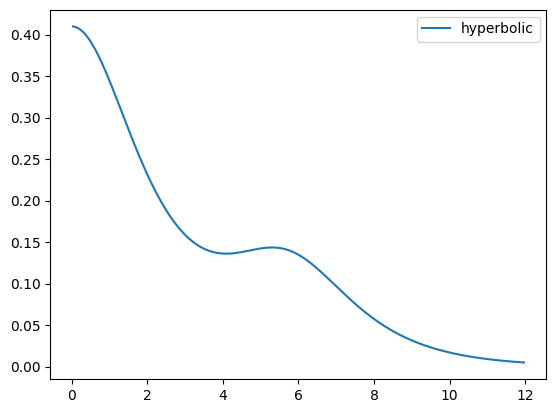

[0.62398477 2.47087786 0.37736639 2.48235592 5.68348361]


In [ ]:
#n=1
jj_in = np.array([
    -0.25000000000000000000,4.50000000000000000000,-238.50000000000000000000,19368.00000000000000000000,-2165620.50000000000000000000,317842321.50000000000000000000,-59155482330.00000000000000000000,13549820391900.00000000000000000000,-3709708445407668.50000000000000000000,1180143948105995008.00000000000000000000
    ], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

res = summary(jj_in*4, (8,10), 1.1, p001)
print(res)

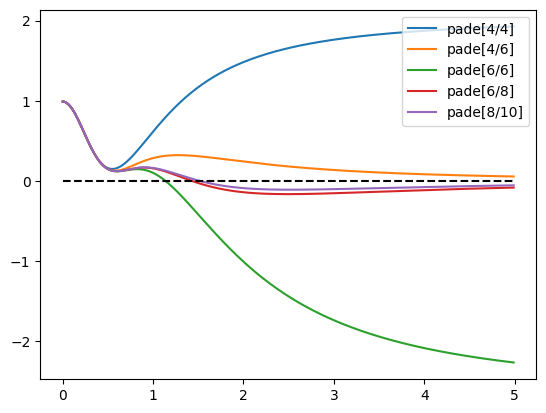

[0.61197229 2.38028551 0.37938031 2.49524097 5.65623077]
[0.33231284 0.82747809 0.65618495 1.95647491 4.25232926]
[0.78172906 2.59701642 0.21544511 1.48377136 6.03573146]


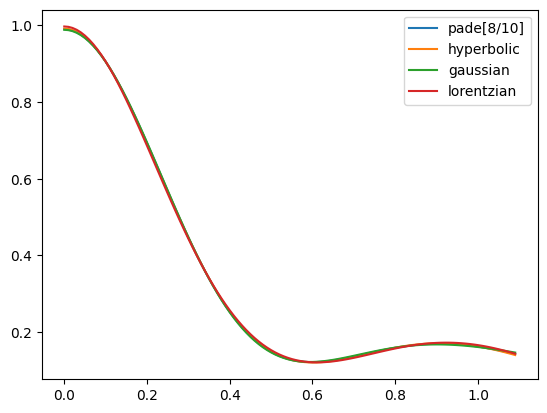

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.41733910867014834
slope_hyp = 2.396132974900199
Tsigma(omega) = [0.41733911 0.41672622 0.41550541 0.4136865  0.41128401 0.40831687
 0.40480807 0.40078429 0.3962754  0.39131401 0.3859349  0.38017456
 0.37407064 0.36766143 0.36098544 0.35408093 0.3469855  0.3397358
 0.33236719 0.32491348 0.31740679 0.30987734 0.30235338 0.29486111
 0.28742464 0.28006603 0.27280528 0.26566038 0.25864744 0.25178069
 0.24507265 0.23853418 0.23217463 0.22600192 0.22002266 0.21424227
 0.20866507 0.2032944  0.19813268 0.19318155 0.18844191 0.18391403
 0.17959762 0.17549185 0.17159548 0.16790685 0.16442398 0.16114455
 0.15806597 0.15518544 0.15249988 0.15000606 0.14770052 0.14557963
 0.14363959 0.14187642 0.14028594 0.13886381 0.13760547 0.13650616
 0.13556088 0.13476441 0.13411124 0.13359559 0.13321137 0.13295215
 0.13281116 0.13278125 0.1328549  0.13302415 0.13328065 0.13361561
 0.13401981 0.1344836  0.13499694 0.13554937 0.13613009 0.136727

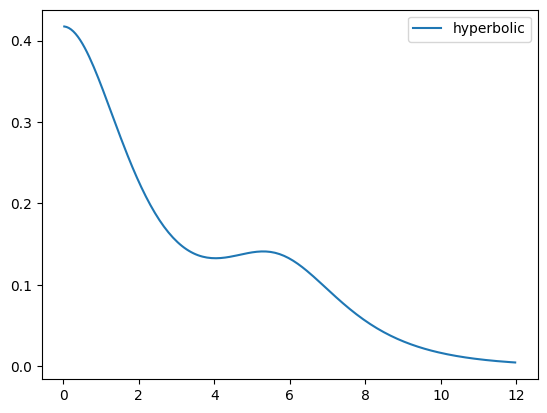

[0.61197229 2.38028551 0.37938031 2.49524097 5.65623077]


In [ ]:
#n=0.9
jj_in = np.array([
    -0.24750000000000002554,4.41045000000000264606,-233.75385000000008517418,18979.40127599991319584660,-2120786.05265999585390090942,310838534.44067746400833129883,-57729048692.12611389160156250000,13187571639708.70507812500000000000,-3600141337521104.50000000000000000000,1142159178031242240.00000000000000000000
    ], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

res = summary(jj_in*4, (8,10), 1.1, p001)
print(res)

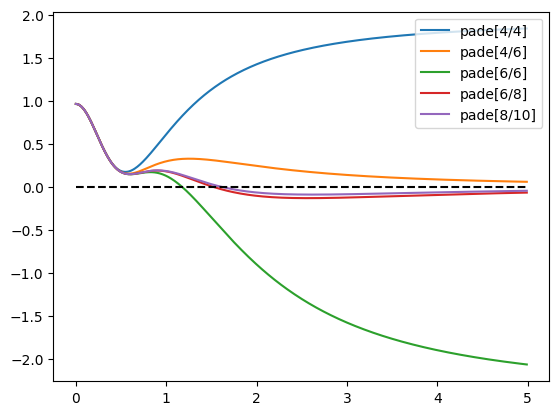

[0.58217127 2.14699826 0.37919864 2.52287771 5.58326313]
[0.33775121 0.77533191 0.62084574 1.96181892 4.23330025]
[0.72998313 2.30034866 0.23345621 1.57084273 6.05077171]


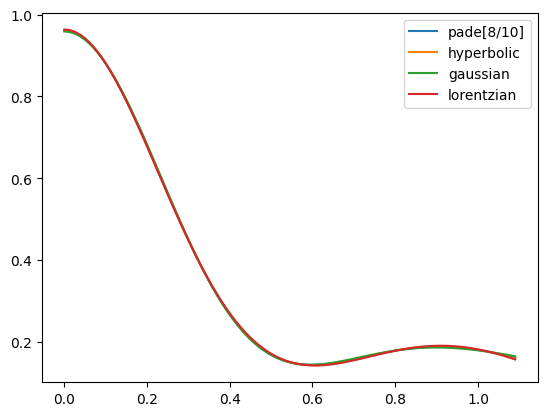

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.4404183498899128
slope_hyp = 2.270568427155591
Tsigma(omega) = [0.44041835 0.43961944 0.4380295  0.43566411 0.43254618 0.42870545
 0.42417784 0.41900464 0.4132317  0.40690852 0.40008733 0.39282216
 0.38516799 0.37717989 0.36891232 0.36041844 0.35174955 0.34295459
 0.33407984 0.32516857 0.31626089 0.30739362 0.29860025 0.28991096
 0.2813527  0.27294927 0.2647215  0.25668738 0.24886229 0.24125912
 0.23388852 0.22675911 0.2198776  0.21324906 0.20687705 0.2007638
 0.19491035 0.18931675 0.18398212 0.17890482 0.17408254 0.16951242
 0.16519109 0.16111481 0.15727948 0.15368073 0.15031395 0.14717434
 0.14425695 0.14155669 0.13906836 0.13678666 0.13470618 0.13282145
 0.13112689 0.12961684 0.12828552 0.12712705 0.12613539 0.12530438
 0.12462767 0.12409873 0.12371079 0.12345688 0.12332972 0.1233218
 0.12342525 0.12363192 0.12393328 0.12432048 0.12478428 0.12531511
 0.12590301 0.12653769 0.12720855 0.12790467 0.12861489 0.12932785

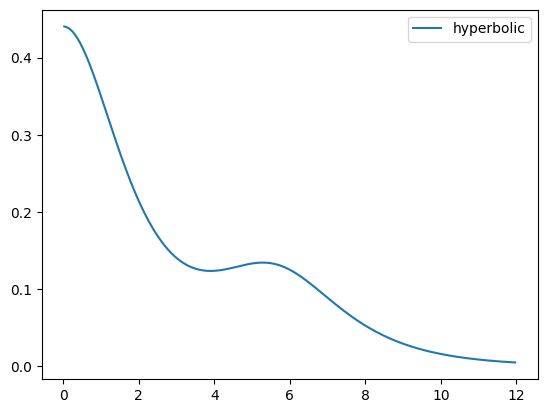

[0.58217127 2.14699826 0.37919864 2.52287771 5.58326313]


In [ ]:
#n=0.8
jj_in = np.array([
    -0.23999999999999999112,4.14719999999999977547,-219.80159999999995079634,17837.60486399992805672809,-1989296.54783999524079263210,290374035.84330713748931884766,-53583504259.01075744628906250000,12141240546827.57031250000000000000,-3285527052144337.00000000000000000000,1033648438345567744.00000000000000000000
    ], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

res = summary(jj_in*4, (8,10), 1.1, p001)
print(res)

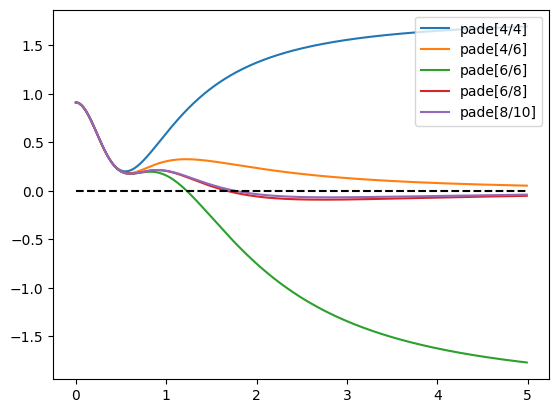

[0.54529059 1.84534973 0.36608906 2.55300519 5.47980687]
[0.34625821 0.70153334 0.56249791 1.96985865 4.20667665]
[0.64667956 1.84925518 0.26544815 1.74989901 5.94394957]


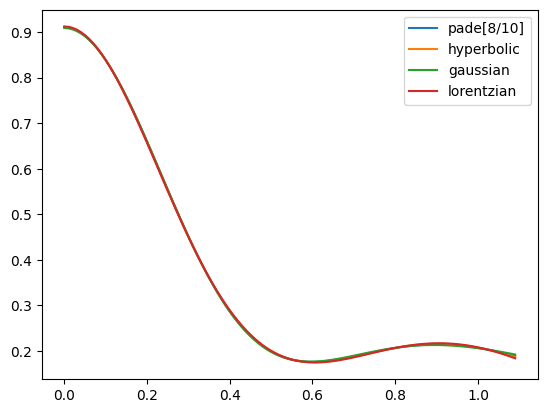

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.47946240133002677
slope_hyp = 2.085669277144577
Tsigma(omega) = [0.4794624  0.4782758  0.47591826 0.47242064 0.46782801 0.46219832
 0.45560067 0.44811339 0.43982194 0.4308168  0.42119135 0.41103988
 0.40045582 0.38953013 0.37835001 0.3669978  0.35555021 0.34407776
 0.33264442 0.32130753 0.31011776 0.29911937 0.28835041 0.27784311
 0.26762429 0.25771578 0.24813491 0.23889495 0.23000555 0.22147318
 0.21330152 0.20549188 0.1980435  0.19095386 0.18421902 0.1778338
 0.17179206 0.16608686 0.16071064 0.15565539 0.15091273 0.14647405
 0.1423306  0.13847353 0.13489398 0.13158312 0.12853218 0.12573247
 0.12317542 0.12085257 0.11875557 0.11687618 0.1152063  0.11373789
 0.112463   0.11137376 0.11046231 0.10972082 0.10914143 0.10871627
 0.10843738 0.10829669 0.10828605 0.1083971  0.10862136 0.1089501
 0.10937439 0.10988507 0.11047272 0.11112765 0.11183994 0.1125994
 0.11339562 0.11421795 0.1150556  0.11589759 0.11673289 0.11755043

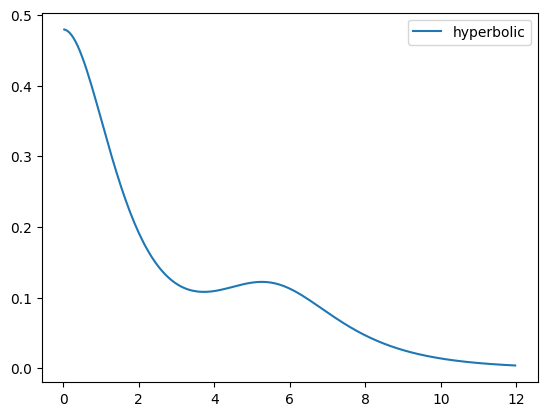

[0.54529059 1.84534973 0.36608906 2.55300519 5.47980687]


In [ ]:
#n=0.7
jj_in = np.array([
    -0.22749999999999998002,3.72644999999999848583,-197.50184999999996193765,16014.49340399999709916301,-1780129.63673999253660440445,258062410.26147258281707763672,-47108976990.60847473144531250000,10527424155466.76171875000000000000,-2806139868088238.00000000000000000000,870061191176669312.00000000000000000000
    ], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

res = summary(jj_in*4, (8,10), 1.1, p001)
print(res)

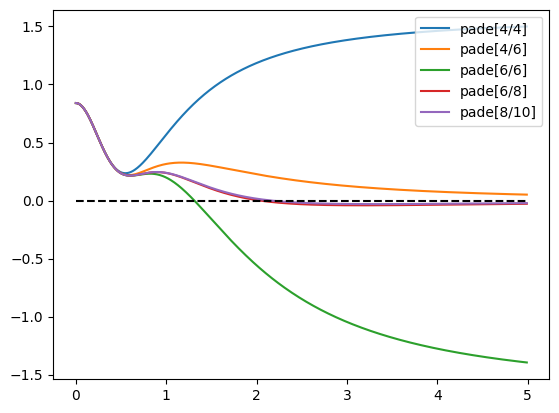

[0.50727371 1.5337481  0.33405952 2.58699892 5.35781142]
[0.35489671 0.61604996 0.48407004 1.98102422 4.1727531 ]
[0.57625229 1.45527513 0.2657394  1.82281076 5.81574457]


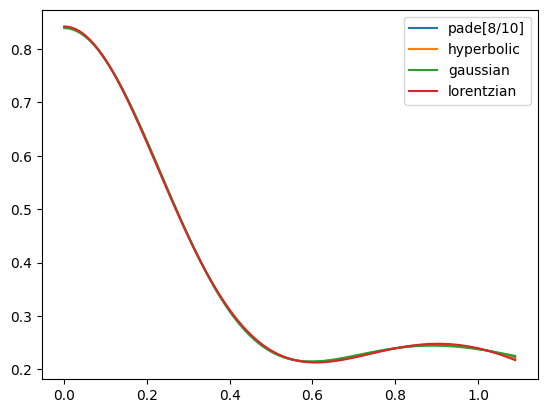

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.5349405537045719
slope_hyp = 1.869366592371427
Tsigma(omega) = [0.53494055 0.53300704 0.52917657 0.52352064 0.51614249 0.50717267
 0.49676373 0.48508431 0.4723132  0.45863346 0.44422725 0.42927119
 0.41393269 0.39836712 0.38271584 0.36710504 0.35164532 0.33643174
 0.3215444  0.30704932 0.29299957 0.27943646 0.26639086 0.25388449
 0.24193113 0.23053784 0.21970598 0.20943223 0.19970943 0.19052736
 0.18187338 0.17373304 0.16609052 0.15892905 0.15223126 0.14597948
 0.1401559  0.13474284 0.12972282 0.12507872 0.12079384 0.11685196
 0.11323739 0.10993501 0.10693023 0.10420907 0.10175805 0.09956427
 0.09761532 0.0958993  0.09440474 0.0931206  0.09203625 0.09114135
 0.09042592 0.08988021 0.08949469 0.08926004 0.08916706 0.08920665
 0.08936978 0.08964745 0.09003064 0.0905103  0.09107734 0.09172254
 0.09243662 0.09321013 0.09403356 0.09489722 0.09579133 0.09670601
 0.0976313  0.09855718 0.09947364 0.1003707  0.10123847 0.102067

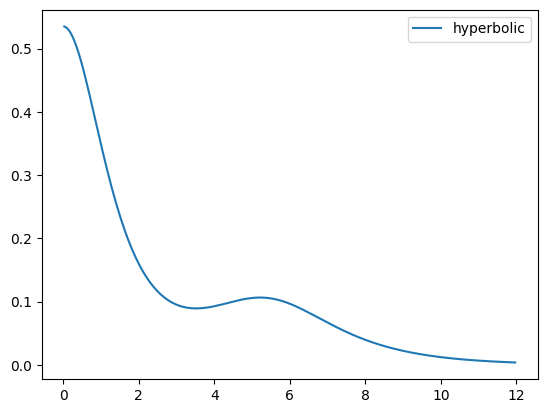

[0.50727371 1.5337481  0.33405952 2.58699892 5.35781142]


In [ ]:
#n=0.6
jj_in = np.array([
    -0.20999999999999999223,3.17519999999999935625,-168.28560000000010177246,13629.48249599993869196624,-1508035.20336000667884945869,216503575.44309765100479125977,-38919136822.61341857910156250000,8525331109322.79101562500000000000,-2222685643022853.00000000000000000000,674317419602083072.00000000000000000000
    ], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

res = summary(jj_in*4, (8,10), 1.1, p001)
print(res)

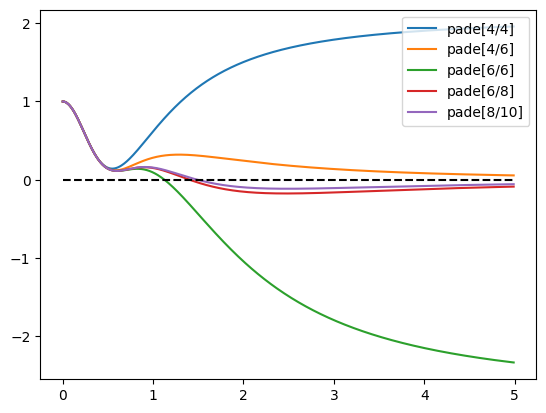

[0.62398477 2.47087786 0.37736639 2.48235592 5.68348361]
[0.33057793 0.84666645 0.66788595 1.95449049 4.25964989]
[0.79026896 2.66350887 0.21846799 1.51065799 5.99075463]


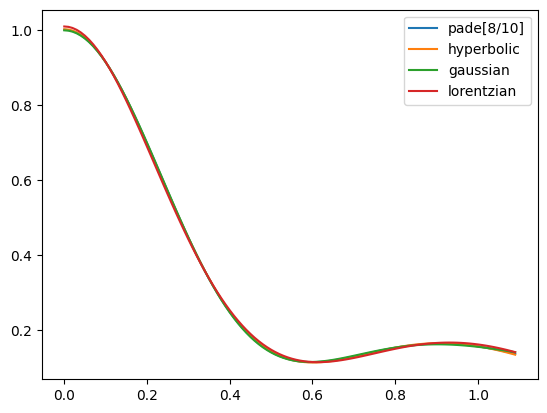

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.4096986034795224
slope_hyp = 2.4408186689120166
Tsigma(omega) = [0.4096986  0.40914109 0.40803027 0.40637447 0.40418601 0.40148097
 0.39827894 0.3946027  0.39047783 0.38593233 0.3809962  0.37570105
 0.3700796  0.36416534 0.35799211 0.3515937  0.34500357 0.33825448
 0.33137828 0.32440565 0.31736594 0.31028699 0.30319504 0.29611462
 0.28906856 0.2820779  0.27516197 0.26833835 0.26162294 0.25503002
 0.24857232 0.24226109 0.23610619 0.23011618 0.2242984  0.21865905
 0.21320331 0.20793541 0.2028587  0.19797576 0.19328844 0.18879794
 0.1845049  0.18040944 0.17651119 0.17280939 0.1693029  0.16599024
 0.16286962 0.15993899 0.15719605 0.15463827 0.15226288 0.15006693
 0.14804725 0.14620047 0.14452302 0.14301114 0.14166082 0.14046784
 0.13942773 0.13853578 0.13778698 0.13717603 0.13669731 0.13634484
 0.13611231 0.135993   0.1359798  0.13606515 0.13624108 0.13649916
 0.13683051 0.13722581 0.13767528 0.13816872 0.13869553 0.13924

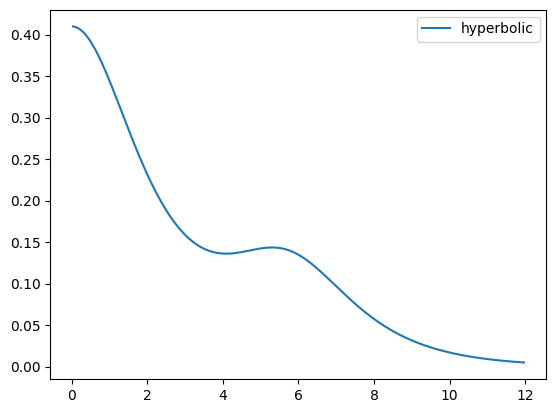

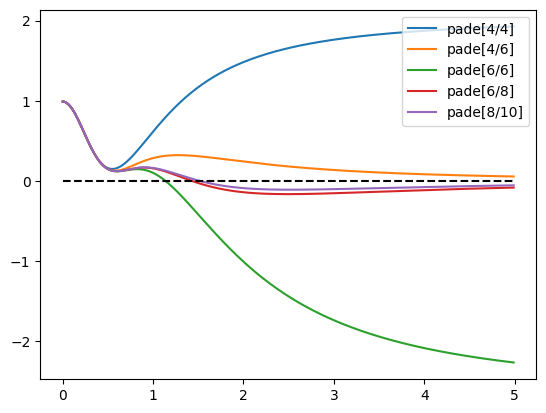

[0.61197229 2.38028551 0.37938031 2.49524097 5.65623077]
[0.33231284 0.82747809 0.65618495 1.95647491 4.25232926]
[0.78172906 2.59701642 0.21544511 1.48377136 6.03573146]


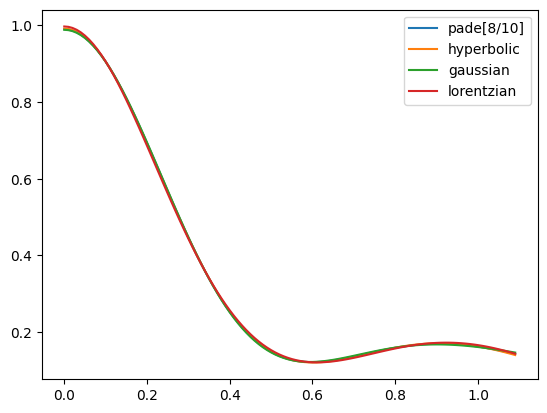

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.41733910867014834
slope_hyp = 2.396132974900199
Tsigma(omega) = [0.41733911 0.41672622 0.41550541 0.4136865  0.41128401 0.40831687
 0.40480807 0.40078429 0.3962754  0.39131401 0.3859349  0.38017456
 0.37407064 0.36766143 0.36098544 0.35408093 0.3469855  0.3397358
 0.33236719 0.32491348 0.31740679 0.30987734 0.30235338 0.29486111
 0.28742464 0.28006603 0.27280528 0.26566038 0.25864744 0.25178069
 0.24507265 0.23853418 0.23217463 0.22600192 0.22002266 0.21424227
 0.20866507 0.2032944  0.19813268 0.19318155 0.18844191 0.18391403
 0.17959762 0.17549185 0.17159548 0.16790685 0.16442398 0.16114455
 0.15806597 0.15518544 0.15249988 0.15000606 0.14770052 0.14557963
 0.14363959 0.14187642 0.14028594 0.13886381 0.13760547 0.13650616
 0.13556088 0.13476441 0.13411124 0.13359559 0.13321137 0.13295215
 0.13281116 0.13278125 0.1328549  0.13302415 0.13328065 0.13361561
 0.13401981 0.1344836  0.13499694 0.13554937 0.13613009 0.136727

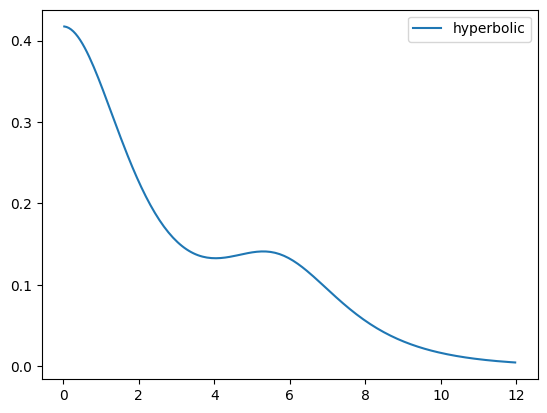

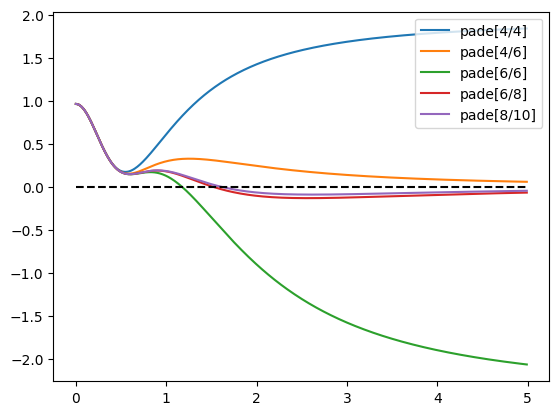

[0.58217127 2.14699826 0.37919864 2.52287771 5.58326313]
[0.33775121 0.77533191 0.62084574 1.96181892 4.23330025]
[0.72998313 2.30034866 0.23345621 1.57084273 6.05077171]


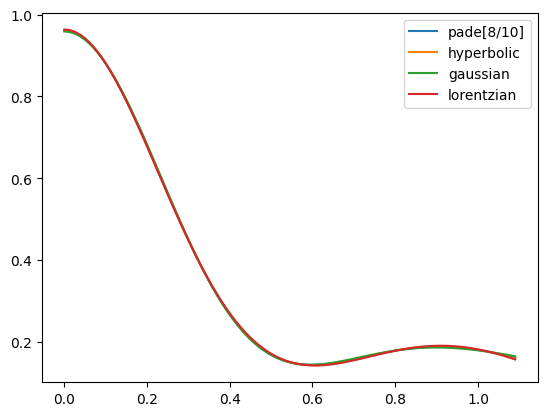

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.4404183498899128
slope_hyp = 2.270568427155591
Tsigma(omega) = [0.44041835 0.43961944 0.4380295  0.43566411 0.43254618 0.42870545
 0.42417784 0.41900464 0.4132317  0.40690852 0.40008733 0.39282216
 0.38516799 0.37717989 0.36891232 0.36041844 0.35174955 0.34295459
 0.33407984 0.32516857 0.31626089 0.30739362 0.29860025 0.28991096
 0.2813527  0.27294927 0.2647215  0.25668738 0.24886229 0.24125912
 0.23388852 0.22675911 0.2198776  0.21324906 0.20687705 0.2007638
 0.19491035 0.18931675 0.18398212 0.17890482 0.17408254 0.16951242
 0.16519109 0.16111481 0.15727948 0.15368073 0.15031395 0.14717434
 0.14425695 0.14155669 0.13906836 0.13678666 0.13470618 0.13282145
 0.13112689 0.12961684 0.12828552 0.12712705 0.12613539 0.12530438
 0.12462767 0.12409873 0.12371079 0.12345688 0.12332972 0.1233218
 0.12342525 0.12363192 0.12393328 0.12432048 0.12478428 0.12531511
 0.12590301 0.12653769 0.12720855 0.12790467 0.12861489 0.12932785

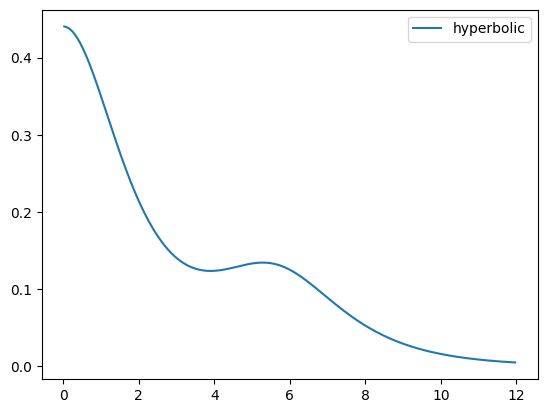

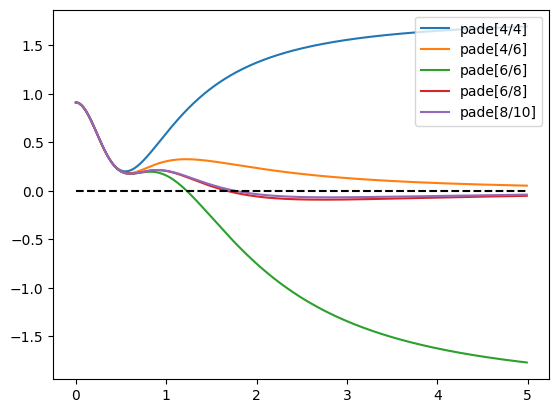

[0.54529059 1.84534973 0.36608906 2.55300519 5.47980687]
[0.34625821 0.70153334 0.56249791 1.96985865 4.20667665]
[0.64667956 1.84925518 0.26544815 1.74989901 5.94394957]


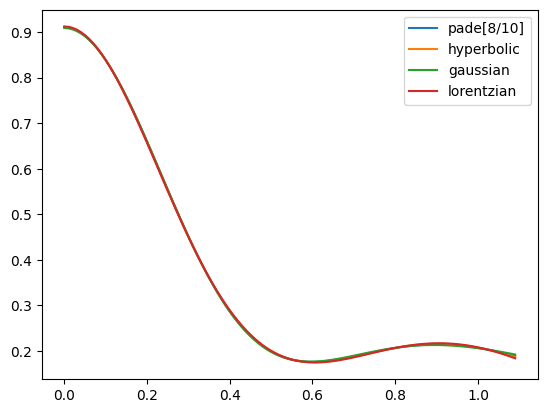

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.47946240133002677
slope_hyp = 2.085669277144577
Tsigma(omega) = [0.4794624  0.4782758  0.47591826 0.47242064 0.46782801 0.46219832
 0.45560067 0.44811339 0.43982194 0.4308168  0.42119135 0.41103988
 0.40045582 0.38953013 0.37835001 0.3669978  0.35555021 0.34407776
 0.33264442 0.32130753 0.31011776 0.29911937 0.28835041 0.27784311
 0.26762429 0.25771578 0.24813491 0.23889495 0.23000555 0.22147318
 0.21330152 0.20549188 0.1980435  0.19095386 0.18421902 0.1778338
 0.17179206 0.16608686 0.16071064 0.15565539 0.15091273 0.14647405
 0.1423306  0.13847353 0.13489398 0.13158312 0.12853218 0.12573247
 0.12317542 0.12085257 0.11875557 0.11687618 0.1152063  0.11373789
 0.112463   0.11137376 0.11046231 0.10972082 0.10914143 0.10871627
 0.10843738 0.10829669 0.10828605 0.1083971  0.10862136 0.1089501
 0.10937439 0.10988507 0.11047272 0.11112765 0.11183994 0.1125994
 0.11339562 0.11421795 0.1150556  0.11589759 0.11673289 0.11755043

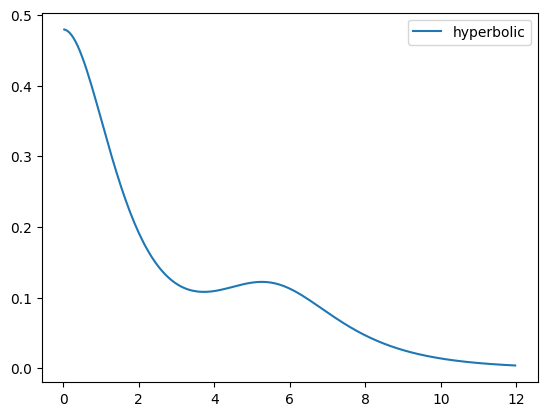

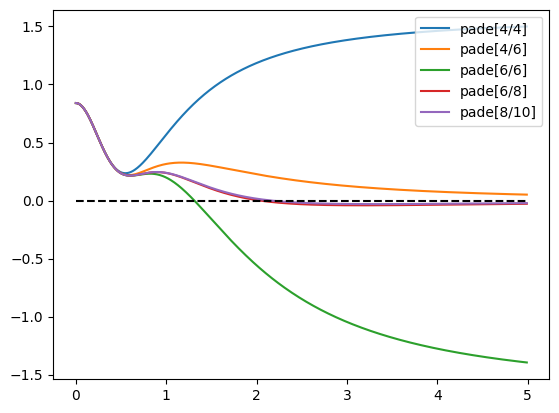

[0.50727371 1.5337481  0.33405952 2.58699892 5.35781142]
[0.35489671 0.61604996 0.48407004 1.98102422 4.1727531 ]
[0.57625229 1.45527513 0.2657394  1.82281076 5.81574457]


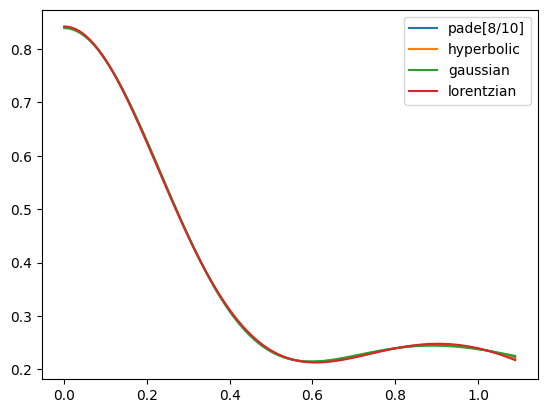

number of omegas = 200
max omega = 11.969999999999999
Tsigma_hyp = 0.5349405537045719
slope_hyp = 1.869366592371427
Tsigma(omega) = [0.53494055 0.53300704 0.52917657 0.52352064 0.51614249 0.50717267
 0.49676373 0.48508431 0.4723132  0.45863346 0.44422725 0.42927119
 0.41393269 0.39836712 0.38271584 0.36710504 0.35164532 0.33643174
 0.3215444  0.30704932 0.29299957 0.27943646 0.26639086 0.25388449
 0.24193113 0.23053784 0.21970598 0.20943223 0.19970943 0.19052736
 0.18187338 0.17373304 0.16609052 0.15892905 0.15223126 0.14597948
 0.1401559  0.13474284 0.12972282 0.12507872 0.12079384 0.11685196
 0.11323739 0.10993501 0.10693023 0.10420907 0.10175805 0.09956427
 0.09761532 0.0958993  0.09440474 0.0931206  0.09203625 0.09114135
 0.09042592 0.08988021 0.08949469 0.08926004 0.08916706 0.08920665
 0.08936978 0.08964745 0.09003064 0.0905103  0.09107734 0.09172254
 0.09243662 0.09321013 0.09403356 0.09489722 0.09579133 0.09670601
 0.0976313  0.09855718 0.09947364 0.1003707  0.10123847 0.102067

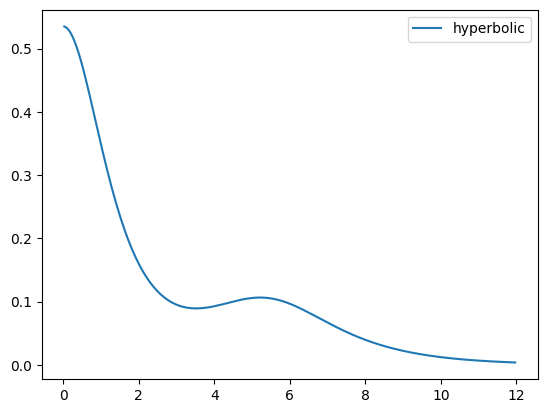

In [ ]:
jj_1 = np.array([
    -0.25000000000000000000,4.50000000000000000000,-238.50000000000000000000,19368.00000000000000000000,-2165620.50000000000000000000,317842321.50000000000000000000,-59155482330.00000000000000000000,13549820391900.00000000000000000000,-3709708445407668.50000000000000000000,1180143948105995008.00000000000000000000
    ], dtype=float)
jj_0p9 = np.array([
    -0.24750000000000002554,4.41045000000000264606,-233.75385000000008517418,18979.40127599991319584660,-2120786.05265999585390090942,310838534.44067746400833129883,-57729048692.12611389160156250000,13187571639708.70507812500000000000,-3600141337521104.50000000000000000000,1142159178031242240.00000000000000000000
    ], dtype=float)
jj_0p8 = np.array([
    -0.23999999999999999112,4.14719999999999977547,-219.80159999999995079634,17837.60486399992805672809,-1989296.54783999524079263210,290374035.84330713748931884766,-53583504259.01075744628906250000,12141240546827.57031250000000000000,-3285527052144337.00000000000000000000,1033648438345567744.00000000000000000000
    ], dtype=float)
jj_0p7 = np.array([
    -0.22749999999999998002,3.72644999999999848583,-197.50184999999996193765,16014.49340399999709916301,-1780129.63673999253660440445,258062410.26147258281707763672,-47108976990.60847473144531250000,10527424155466.76171875000000000000,-2806139868088238.00000000000000000000,870061191176669312.00000000000000000000
    ], dtype=float)
jj_0p6 = np.array([
    -0.20999999999999999223,3.17519999999999935625,-168.28560000000010177246,13629.48249599993869196624,-1508035.20336000667884945869,216503575.44309765100479125977,-38919136822.61341857910156250000,8525331109322.79101562500000000000,-2222685643022853.00000000000000000000,674317419602083072.00000000000000000000
    ], dtype=float)

p001 = np.array([0.5,2,0.5,3,6])

res_1 = summary(jj_1*4, (8,10), 1.1, p001)
res_0p9 = summary(jj_0p9*4, (8,10), 1.1, p001)
res_0p8 = summary(jj_0p8*4, (8,10), 1.1, p001)
res_0p7 = summary(jj_0p7*4, (8,10), 1.1, p001)
res_0p6 = summary(jj_0p6*4, (8,10), 1.1, p001)


In [ ]:
def T_sigma_from_summary_input(jj,order=(8,10),bound=1.1,p00=p001):
    taylor = taylor_ex(jj)
    orders = np.array([(4,4),(4,6),(6,6),(6,8),order])

    for order in orders:
        order1, order2 = order
        p,q = pade(taylor,order2,order1)

        x = np.arange(0,5,0.01)
        y = p(x)/q(x)

    ts = np.arange(0,bound,0.01)
    ys = p(ts)/q(ts)
    popt, pcov = curve_fit(fitfun_hyperbolic, ts, ys,p0 =p00,maxfev = 12000,
                           bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
    dw = 0.06
    ws = np.arange(0.03,12.0,dw)
    sigma2t = np.zeros(ws.size)
    for i, w in enumerate(ws):
        sigma2t[i] = fft_to_2tsigma(w,*popt,"hyperbolic")
    maxT = 8
    A = sigma2t/2 * dw / maxT / np.pi
    A = A / A.sum()

    return ws, sigma2t/2

In [ ]:
pip install cmcrameri

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.4/277.4 kB 10.2 MB/s eta 0:00:00


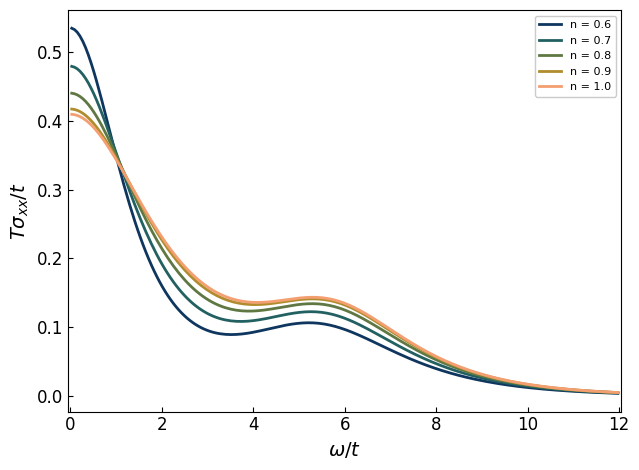

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cmcrameri import cm

color_by_n = {
    0.6: cm.batlow(0.08),
    0.7: cm.batlow(0.25),
    0.8: cm.batlow(0.42),
    0.9: cm.batlow(0.59),
    1.0: cm.batlow(0.76),
}

datasets = [
    ("n = 0.6", jj_0p6 * 4, color_by_n[0.6]),
    ("n = 0.7", jj_0p7 * 4, color_by_n[0.7]),
    ("n = 0.8", jj_0p8 * 4, color_by_n[0.8]),
    ("n = 0.9", jj_0p9 * 4, color_by_n[0.9]),
    ("n = 1.0", jj_1 * 4, color_by_n[1.0]),
]

fig, ax = plt.subplots(figsize=(6.5, 4.8))

for label, jj_data, color in datasets:
    ws, T_sigma = T_sigma_from_summary_input(
        jj_data,
        order=(8, 10),
        bound=1.1,
        p00=p001,
    )
    ax.plot(ws, T_sigma, label=label, color=color, linewidth=2)

ax.set_xlabel(r"$\omega/t$", fontsize=14)
ax.set_ylabel(r"$T\sigma_{xx}/t$", fontsize=14)
ax.set_xlim(left=-0.05, right=12.05)

ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    labelsize=12,
)

leg = ax.legend(
    frameon=True,
    fancybox=True,
    framealpha=0.8,
    edgecolor="0.75",
    facecolor="white",
    fontsize=8,
)

fig.tight_layout()

fig.savefig("/content/T_sigma_overlay.png", dpi=300, bbox_inches="tight")
fig.savefig("/content/T_sigma_overlay.pdf", bbox_inches="tight")